# Airline Sentiment Analysis using Naive Bayes
This notebook analyzes customer feedback from airline tweets to classify sentiment as either positive or negative.
* **Text Preprocessing:** Lowercasing, removing URLs, and stripping @mentions to reduce noise, followed by `CountVectorizer`.
* **Model:** `MultinomialNB`.
* **Evaluation:** Assessing performance on complex sentiment data compared to basic spam filtering.

,Accuracy,Precision,Recall,F1-Score
Naive Bayes (Sentiment),0.913816,0.916107,0.610738,0.732886


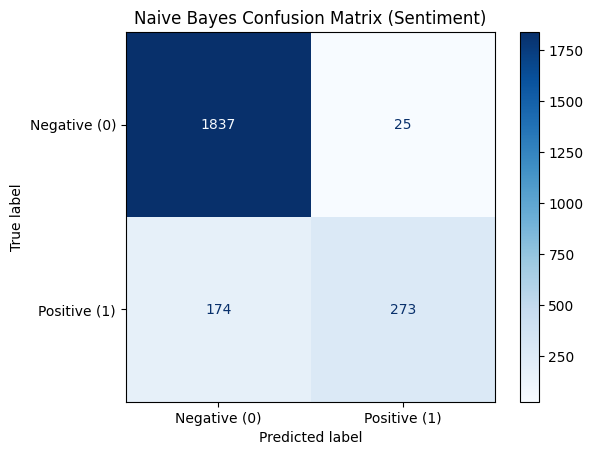

In [2]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Load Data and Drop Neutral
Tweets = pd.read_csv('/kaggle/input/datasets/crowdflower/twitter-airline-sentiment/Tweets.csv')
Tweets_binary = Tweets[Tweets['airline_sentiment'] != 'neutral'].copy()

# 2. Text Cleaning Function
def clean_tweet(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) 
    text = re.sub(r'@\w+', '', text) 
    return text

Tweets_binary['clean_text'] = Tweets_binary['text'].apply(clean_tweet)

# 3. Encode, Split, and Vectorize
Tweets_binary['label_encoded'] = Tweets_binary['airline_sentiment'].map({'negative': 0, 'positive': 1})
X_train, X_test, y_train, y_test = train_test_split(
    Tweets_binary['clean_text'], Tweets_binary['label_encoded'], test_size=0.2, random_state=42
)

vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# 4. Train Model
nb_model_sentiment = MultinomialNB()
nb_model_sentiment.fit(X_train_vec, y_train)
y_pred_sentiment = nb_model_sentiment.predict(X_test_vec)

# 5. Evaluate and Display Metrics
metrics_df_sentiment = pd.DataFrame({
    'Accuracy': [accuracy_score(y_test, y_pred_sentiment)],
    'Precision': [precision_score(y_test, y_pred_sentiment)],
    'Recall': [recall_score(y_test, y_pred_sentiment)],
    'F1-Score': [f1_score(y_test, y_pred_sentiment)]
}, index=['Naive Bayes (Sentiment)'])
display(metrics_df_sentiment)

# 6. Plot Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_sentiment, 
    cmap='Blues', 
    display_labels=['Negative (0)', 'Positive (1)']
)
plt.title("Naive Bayes Confusion Matrix (Sentiment)")
plt.show()